In [136]:
#Load dataset using sklearn.
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000,n_features=5,random_state=42,n_classes=2)
#Split dataset into train and test sets.
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [137]:
#Normalize dataset using MinMaxScaler.
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler=MinMaxScaler(feature_range=(0,1),copy=True,clip=False)
x_train_n=scaler.fit_transform(x_train)
x_test_n=scaler.fit_transform(x_test)
#Standardize dataset using StandardScaler.
scaler_n=StandardScaler()
x_train_t=scaler_n.fit_transform(x_train)
x_test_t=scaler_n.fit_transform(x_test)


In [138]:
#Encode categorical data using LabelEncoder.
import pandas as pd
data=pd.DataFrame({
    "name":["ALI","Ahemd","Noman","Usman","Usama"],
    "Disease":["yes","No","yes","No","yes"]
})
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data['name_l']=encoder.fit_transform(data['name'])
data['Disease_l']=encoder.fit_transform(data['Disease'])
data

,name,Disease,name_l,Disease_l
0,ALI,yes,0,1
1,Ahemd,No,1,0
2,Noman,yes,2,1
3,Usman,No,4,0
4,Usama,yes,3,1


In [139]:
#Apply OneHotEncoder on dataset.
from sklearn.preprocessing import OneHotEncoder
hotencoder=OneHotEncoder(sparse_output=False)
dat=hotencoder.fit_transform(data[['name','Disease']])
data_n=pd.DataFrame(dat)

In [140]:
#Handle missing values using SimpleImputer.
data=pd.DataFrame({
    "age":[12,None,23,24,None,18,None,21]
})
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="mean")
data['age']=imputer.fit_transform(data[["age"]])
data

,age
0,12.0
1,19.6
2,23.0
3,24.0
4,19.6
5,18.0
6,19.6
7,21.0


****
# Linear Regression

In [141]:
#Train simple linear regression model.
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_n,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


291725.04
accuracy Score: 0.9110096522219988(91.10%)


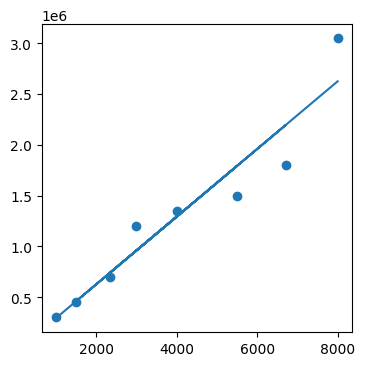

In [142]:
#Predict house prices using linear regression.
import numpy as np
data=pd.DataFrame({
    "sqft":[1000,5500,3000,4004,1500,6706,2345,8000],
    "prices":[300000,1500000,1200000,1350000,455000,1800000,700000,3050000]
})
x=data['sqft'].values.reshape(-1,1)
y=data['prices']
model=LinearRegression()
model.fit(x,y)
prediction=model.predict(x)
acc=r2_score(y,prediction)
print(f"{prediction[0]:.2f}\naccuracy Score: {acc}({acc*100:.2f}%)")
#Plot regression line.
import matplotlib.pyplot as pl
pl.figure(figsize=(4,4))
pl.plot(x,prediction)
pl.scatter(x,y)
pl.show()

In [143]:
#Train multiple linear regression model.
data=pd.DataFrame({
    "sqft":[1000,5500,3000,4004,1500,6706,2345,8000],
    "bedroom":[1,3,3,2,2,4,3,6],
    "Age":[1,2,5,4,3,6,7,3],
    "prices":[300000,1500000,1200000,1350000,455000,1800000,700000,3050000]
})
x=data[['sqft','bedroom','Age']].values
y=data['prices'].values
model=LinearRegression()
model.fit(x,y)
prediction=model.predict(x)
acc=r2_score(y,prediction)
print(f"{prediction[0]:.2f}\naccuracy Score: {acc}({acc*100:.2f}%)")

newpred=model.predict([[5000,4,2]])
print(newpred)

320774.87
accuracy Score: 0.9551349052723302(95.51%)
[1858904.75538807]
